In [5]:
subject = ['sub-16880', 'sub-41810', 'sub-12400', 'sub-14870']
root = '/scratch/user/uqxye5/segmentation/ALMRI/results/dice'
inference_root = '/scratch/user/uqxye5/segmentation/ALMRI/inference_outputs'
entropy_folder = 'trainingset_51_entropy'
random_folder = ['trainingset_51_randoms2021', 'trainingset_51_randoms2022', 'trainingset_51_randoms2023', 'trainingset_51_randoms2024', 'trainingset_51_randoms2025']


In [6]:
import json
import os

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

ORGANS = ["left_kidney", "right_kidney", "pancreas"]
ORGAN_LABELS = ["Left kidney", "Right kidney", "Pancreas"]
# Match raincloud figure (coral / teal / orange)
ORGAN_COLORS = {
    "left_kidney": "#E9978A",
    "right_kidney": "#6DBFB5",
    "pancreas": "#F0AD6E",
}
CASE_SUFFIX = ".FatImaging_W.nii.gz"


def subject_to_case(sub_id: str) -> str:
    return sub_id if sub_id.endswith(".nii.gz") else f"{sub_id}{CASE_SUFFIX}"


def load_per_case_dice(dice_dir: str) -> dict:
    """Return {case_name: {organ: dice, ...}} from dice.json."""
    path = os.path.join(dice_dir, "dice.json")
    with open(path) as f:
        data = json.load(f)
    return {row["case"]: row for row in data["per_case"]}


def collect_dice(root, folder, subjects, organs=ORGANS):
    """Dice values for selected subjects from one result folder."""
    records = load_per_case_dice(os.path.join(root, folder))
    rows = []
    for sub in subjects:
        case = subject_to_case(sub)
        if case not in records:
            raise KeyError(f"{case} not found in {folder}")
        for organ in organs:
            rows.append(
                {
                    "subject": sub,
                    "organ": organ,
                    "dice": records[case][organ],
                    "folder": folder,
                }
            )
    return pd.DataFrame(rows)


ORGAN_LABEL_IDS = {1: "left_kidney", 2: "right_kidney", 3: "pancreas"}


def dice_folder_to_pred_folder(folder: str) -> str:
    """Map results/dice folder name to inference_outputs pred directory."""
    return folder.replace("trainingset_", "pred_trainingset_")


MM3_PER_CM3 = 1000.0


def nifti_voxel_spacing_mm(img: nib.Nifti1Image) -> tuple[float, float, float]:
    """Voxel spacing (mm) from NIfTI affine (absolute values)."""
    zooms = nib.affines.voxel_sizes(img.affine)
    return tuple(float(abs(z)) for z in zooms[:3])


def organ_volumes_from_pred(pred_path: str) -> dict:
    """Per-organ volume (cm³) = n_voxels × voxel_volume_mm³ / 1000."""
    img = nib.load(pred_path)
    data = np.asarray(img.dataobj)
    sx, sy, sz = nifti_voxel_spacing_mm(img)
    voxel_mm3 = sx * sy * sz

    n_voxels = {
        ORGAN_LABEL_IDS[label_id]: int((data == label_id).sum())
        for label_id in ORGAN_LABEL_IDS
    }
    volume_cm3 = {
        organ: n_voxels[organ] * voxel_mm3 / MM3_PER_CM3 for organ in n_voxels
    }
    return {
        "spacing_mm": (sx, sy, sz),
        "voxel_mm3": voxel_mm3,
        "n_voxels": n_voxels,
        "volume_cm3": volume_cm3,
    }


def collect_volumes(inference_root, folder, subjects, organs=ORGANS):
    """Organ volumes (cm³) using each file's own voxel spacing."""
    pred_dir = os.path.join(inference_root, dice_folder_to_pred_folder(folder))
    rows = []
    for sub in subjects:
        case = subject_to_case(sub)
        pred_path = os.path.join(pred_dir, case)
        if not os.path.isfile(pred_path):
            raise FileNotFoundError(f"{pred_path} not found")
        parsed = organ_volumes_from_pred(pred_path)
        sx, sy, sz = parsed["spacing_mm"]
        for organ in organs:
            rows.append(
                {
                    "subject": sub,
                    "organ": organ,
                    "volume": parsed["volume_cm3"][organ],
                    "folder": folder,
                    "spacing_x_mm": sx,
                    "spacing_y_mm": sy,
                    "spacing_z_mm": sz,
                    "voxel_volume_mm3": parsed["voxel_mm3"],
                    "n_voxels": parsed["n_voxels"][organ],
                }
            )
    return pd.DataFrame(rows)

In [7]:
# Random sampling: volumes from segmentation maps (5 seeds × subjects × organs)
random_vol_dfs = [collect_volumes(inference_root, folder, subject) for folder in random_folder]
df_random = pd.concat(random_vol_dfs, ignore_index=True)
df_random["seed"] = df_random["folder"].str.replace("trainingset_51_randoms", "", regex=False)

# Dice (for Figure 2) from results/dice
random_dice_dfs = [collect_dice(root, folder, subject) for folder in random_folder]
df_random_dice = pd.concat(random_dice_dfs, ignore_index=True)

# Entropy baseline for the same subjects
df_entropy = collect_dice(root, entropy_folder, subject)

# Per (subject, organ): mean dice over 5 random seeds
df_random_avg = (
    df_random_dice.groupby(["subject", "organ"], as_index=False)["dice"]
    .mean()
    .rename(columns={"dice": "dice_random_avg"})
)

df_compare = df_random_avg.merge(
    df_entropy[["subject", "organ", "dice"]].rename(columns={"dice": "dice_entropy"}),
    on=["subject", "organ"],
)
df_compare["organ_label"] = df_compare["organ"].map(
    dict(zip(ORGANS, ORGAN_LABELS))
)

print("Random runs:", len(df_random), "rows")
display(df_compare.pivot(index="subject", columns="organ_label", values=["dice_random_avg", "dice_entropy"]))

Random runs: 60 rows


dice_random_avg                        dice_entropy            \
organ_label     Left kidney  Pancreas Right kidney  Left kidney  Pancreas   
subject                                                                     
sub-12400          0.548636  0.000181     0.300666     0.653066  0.000000   
sub-14870          0.452183  0.000293     0.270110     0.570652  0.000824   
sub-16880          0.543152  0.000227     0.428322     0.691538  0.006135   
sub-41810          0.703232  0.000000     0.241491     0.759784  0.000000   

                          
organ_label Right kidney  
subject                   
sub-12400       0.646575  
sub-14870       0.495778  
sub-16880       0.721272  
sub-41810       0.561701

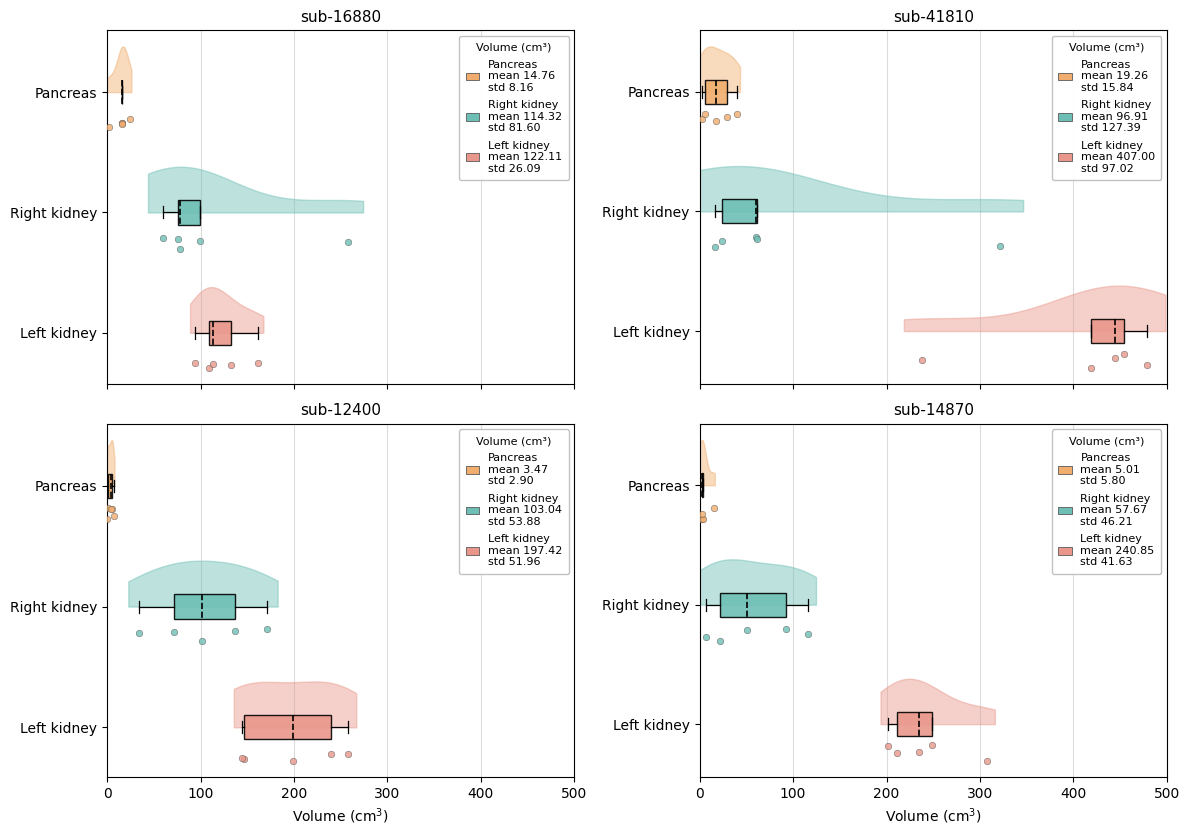

In [67]:
# Figure 1: horizontal raincloud (cm³) — one panel per subject
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde


def plot_raincloud_horizontal(
    ax,
    data,
    x_col,
    y_col,
    order,
    palette,
    *,
    cloud_height=0.38,
    rain_gap=0.24,
    box_w=0.2,
    cloud_alpha=0.45,
    point_size=22,
    rng=None,
):
    """Half-density cloud + box + jittered points (horizontal raincloud)."""
    if rng is None:
        rng = np.random.default_rng(0)
    y_at = {lab: i for i, lab in enumerate(order)}

    for lab in order:
        vals = data.loc[data[y_col] == lab, x_col].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        color = palette[lab]
        y0 = y_at[lab]

        ax.boxplot(
            vals,
            positions=[y0],
            vert=False,
            widths=box_w,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            zorder=3,
            boxprops=dict(facecolor=color, edgecolor="black", alpha=0.9, linewidth=1),
            medianprops=dict(color="black", linestyle="--", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=0.9),
            capprops=dict(color="black", linewidth=0.9),
        )

        jitter = rng.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(
            vals,
            y0 + rain_gap + jitter,
            s=point_size,
            color=color,
            alpha=0.8,
            edgecolors="0.35",
            linewidths=0.4,
            zorder=4,
        )

        if len(vals) >= 2:
            kde = gaussian_kde(vals)
            pad = max(1.0, 0.08 * (vals.max() - vals.min()))
            xs = np.linspace(max(0, vals.min() - pad), vals.max() + pad, 200)
            dens = kde(xs)
            dens = dens / dens.max() * cloud_height
            ax.fill_between(xs, y0 - dens, y0, color=color, alpha=cloud_alpha, zorder=1)

    ax.set_yticks(range(len(order)), order)
    ax.invert_yaxis()


ORGAN_Y_ORDER = ["pancreas", "right_kidney", "left_kidney"]
ORGAN_Y_LABELS = ["Pancreas", "Right kidney", "Left kidney"]
organ_label_map = dict(zip(ORGANS, ORGAN_LABELS))
palette = {organ_label_map[o]: ORGAN_COLORS[o] for o in ORGANS}

vol_max = np.ceil(df_random["volume"].max() / 50) * 50

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
axes = axes.flatten()

for ax, sub in zip(axes, subject):
    sub_df = df_random[df_random["subject"] == sub].copy()
    sub_df["organ_label"] = sub_df["organ"].map(organ_label_map)

    plot_raincloud_horizontal(
        ax,
        sub_df,
        x_col="volume",
        y_col="organ_label",
        order=ORGAN_Y_LABELS,
        palette=palette,
        rng=np.random.default_rng(abs(hash(sub)) % (2**32)),
    )

    ax.set_title(sub, fontsize=11)
    ax.set_xlim(0, vol_max)
    ax.set_axisbelow(True)
    ax.grid(axis="x", color="0.85", linestyle="-", linewidth=0.8, alpha=0.9)
    ax.set_facecolor("white")

    vol_stats = (
        sub_df.groupby("organ_label")["volume"]
        .agg(
            mean="mean",
            std=lambda s: float(s.std(ddof=1)) if len(s) > 1 else 0.0,
        )
        .reindex(ORGAN_Y_LABELS)
    )
    legend_handles = [
        Patch(facecolor=palette[lab], edgecolor="0.35", linewidth=0.6)
        for lab in ORGAN_Y_LABELS
    ]
    legend_labels = [
        f"{lab}\nmean {vol_stats.loc[lab, 'mean']:.2f}\nstd {vol_stats.loc[lab, 'std']:.2f}"
        for lab in ORGAN_Y_LABELS
    ]
    ax.legend(
        legend_handles,
        legend_labels,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="0.75",
        fontsize=8,
        handlelength=1.2,
        labelspacing=0.65,
        borderpad=0.6,
        title="Volume (cm³)",
        title_fontsize=8,
    )

# axes[0].set_ylabel("Organ")
# axes[2].set_ylabel("Organ")
for ax in axes[2:]:
    ax.set_xlabel(r"Volume ($\mathrm{cm}^3$)")
# fig.suptitle(
#     f"Random AL predicted volume — {len(random_folder)} seeds per subject",
#     y=1.06,
#     fontsize=12,
# )
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(root, "random_volume_raincloud_4subjects.pdf"), dpi=300, bbox_inches="tight")
plt.show()

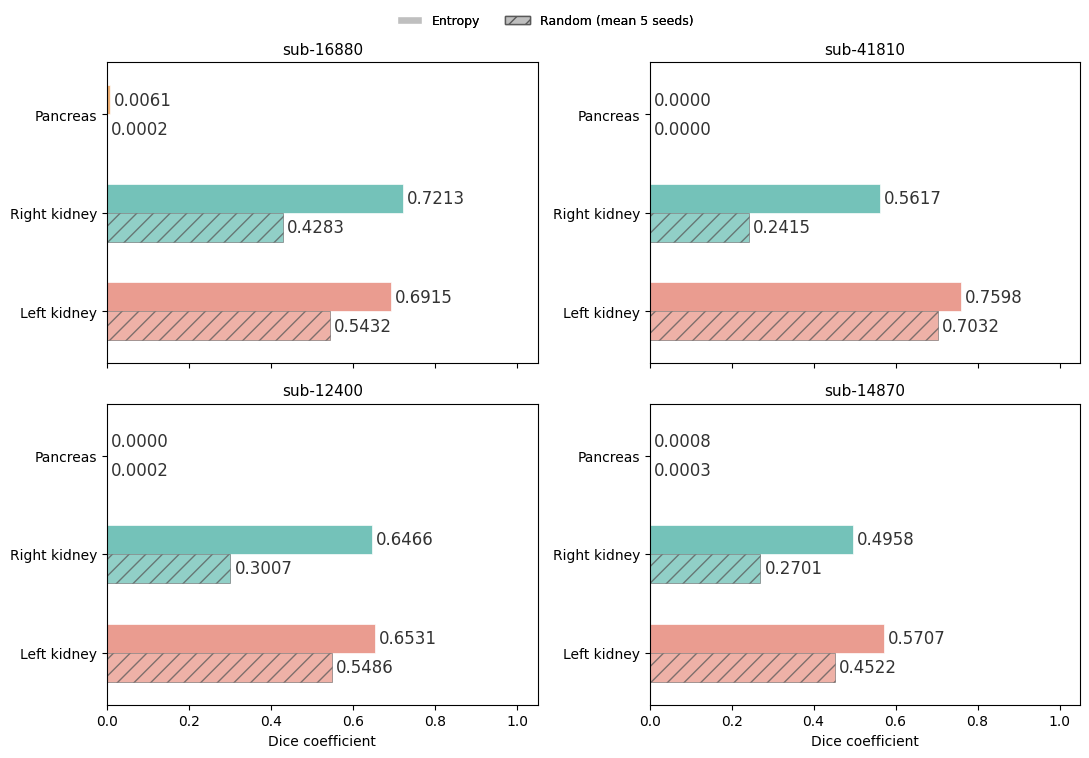

In [17]:
import json
import os

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
# Figure 2: 4 subjects — y = 3 organs, two scores (entropy vs random) per organ
ORGAN_Y_ORDER = ["pancreas", "right_kidney", "left_kidney"]
ORGAN_Y_LABELS = ["Pancreas", "Right kidney", "Left kidney"]

from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.flatten()
bar_h = 0.05
organ_gap = 0.17  # vertical spacing between organ groups
y_pos = np.arange(len(ORGAN_Y_ORDER)) * organ_gap
y_pad = bar_h + 0.04
for ax, sub in zip(axes, subject):
    sub_df = df_compare[df_compare["subject"] == sub].set_index("organ")

    for i, organ in enumerate(ORGAN_Y_ORDER):
        color = ORGAN_COLORS[organ]
        ent = sub_df.loc[organ, "dice_entropy"]
        rnd = sub_df.loc[organ, "dice_random_avg"]

        ax.barh(
            y_pos[i] - bar_h / 2,
            ent,
            height=bar_h,
            color=color,
            edgecolor="white",
            linewidth=0.5,
            alpha=0.95,
        )
        b_rnd = ax.barh(
            y_pos[i] + bar_h / 2,
            rnd,
            height=bar_h,
            color=color,
            edgecolor="0.35",
            linewidth=0.5,
            alpha=0.75,
            hatch="//",
        )
        b_rnd[0].set_hatch("//")

        ax.text(ent + 0.01, y_pos[i] - bar_h / 2, f"{ent:.4f}", va="center", fontsize=12, color="0.2")
        ax.text(rnd + 0.01, y_pos[i] + bar_h / 2, f"{rnd:.4f}", va="center", fontsize=12, color="0.2")

    ax.set_yticks(y_pos, ORGAN_Y_LABELS, fontsize=10)
    ax.set_ylim(y_pos[-1] + y_pad, y_pos[0] - y_pad)
    ax.set_xlim(0, 1.05)
    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_title(sub, fontsize=11)

# axes[0].set_ylabel("Organ")
# axes[2].set_ylabel("Organ")
for ax in axes[2:]:
    ax.set_xlabel("Dice coefficient")

method_handles = [
    Patch(facecolor="0.75", edgecolor="white", label="Entropy"),
    Patch(
        facecolor="0.75",
        edgecolor="0.35",
        hatch="//",
        label=f"Random (mean {len(random_folder)} seeds)",
    ),
]
organ_handles = [
    Patch(facecolor=ORGAN_COLORS[o], edgecolor="white", label=l)
    for o, l in zip(ORGAN_Y_ORDER, ORGAN_Y_LABELS)
]

leg_method = fig.legend(
    handles=method_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
    frameon=False,
    fontsize=9,
    # title="Score type",
    title_fontsize=12,
)
# leg_organs = fig.legend(
#     handles=organ_handles,
#     loc="upper center",
#     bbox_to_anchor=(0.72, 1.01),
#     ncol=3,
#     frameon=False,
#     fontsize=9,
#     title="Organ color",
#     title_fontsize=9,
# )
fig.add_artist(leg_method)

# fig.suptitle(
#     f"Entropy vs random Dice (mean of {len(random_folder)} seeds)",
#     y=1.10,
#     fontsize=12,
# )
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(root, "random_avg_vs_entropy_hist.png"), dpi=150, bbox_inches="tight")
plt.savefig(os.path.join(root, "random_avg_vs_entropy_hist.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [34]:
entropy_45_path = (
    "/scratch/user/uqxye5/segmentation/ALMRI/results/entropy/outliers_45_entropy_seed2025.json"
)
import json

import pandas as pd

with open(entropy_45_path) as f:
    entropy_45 = json.load(f)

entropy_45_df = pd.DataFrame(
    [
        {
            "subject": subject,
            "epistemic_entropy": (
                float(record["epistemic_entropy"])
                if isinstance(record, dict)
                else float(record)
            ),
        }
        for subject, record in entropy_45.items()
    ]
)
# top 10 entropy subjects
entropy_45_df.sort_values("epistemic_entropy", ascending=False).head(10)

,subject,epistemic_entropy
19,sub-41810.FatImaging_W.nii.gz,0.002587
7,sub-16880.FatImaging_W.nii.gz,0.002438
3,sub-12400.FatImaging_W.nii.gz,0.002413
5,sub-14870.FatImaging_W.nii.gz,0.002342
11,sub-19530.FatImaging_W.nii.gz,0.002263
37,sub-50710.FatImaging_W.nii.gz,0.001936
17,sub-41020.FatImaging_W.nii.gz,0.001791
29,sub-48310.FatImaging_W.nii.gz,0.001751
16,sub-40750.FatImaging_W.nii.gz,0.001544
43,sub-52220.FatImaging_W.nii.gz,0.001234


In [14]:
import os

ALMRI_DIR = '/scratch/user/uqxye5/segmentation/ALMRI'
ckp_45_path = os.path.join(
    ALMRI_DIR,
    'checkpoints/DynUNet_trainingset51_entropy_finetune/seed2025/inc30/DynUNet_51subjects_seed2025.pt',
)
outliers_ds_path = os.path.join(ALMRI_DIR, 'datasets/outliers_45')
entropy_json_path = os.path.join(ALMRI_DIR, 'results/entropy/outliers_51_entropy.json')

In [15]:
import json
import sys
from glob import glob
import pandas as pd
import torch
from monai.apps.deepedit.transforms import (
    AddGuidanceFromPointsDeepEditd,
    AddGuidanceSignalDeepEditd,
)
from monai.networks.nets import DynUNet
from monai.transforms import (
    CenterSpatialCropd,
    Compose,
    EnsureChannelFirstd,
    LoadImaged,
    Orientationd,
    ToTensord,
)
sys.path.insert(0, ALMRI_DIR)
from strategy import compute_epistemic_entropy_score
LABELS = {
    "left kidney": 1,
    "right kidney": 2,
    "pancreas": 3,
    "background": 0,
}
NUMBER_INTENSITY_CH = 1
IN_CHANNELS = NUMBER_INTENSITY_CH + len(LABELS)
OUT_CHANNELS = len(LABELS)
SPATIAL_SIZE = (192, 192, 96)
NUM_MC_SAMPLES = 5


def get_network():
    return DynUNet(
        spatial_dims=3,
        in_channels=IN_CHANNELS,
        out_channels=OUT_CHANNELS,
        kernel_size=[3, 3, 3, 3, 3, 3],
        strides=[1, 2, 2, 2, 2, [2, 2, 1]],
        upsample_kernel_size=[2, 2, 2, 2, [2, 2, 1]],
        norm_name="instance",
        deep_supervision=False,
        res_block=True,
    )


infer_transforms = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        Orientationd(keys="image", axcodes="RAS"),
        AddGuidanceFromPointsDeepEditd(
            ref_image="image", guidance="guidance", label_names=LABELS
        ),
        CenterSpatialCropd(keys="image", roi_size=SPATIAL_SIZE),
        AddGuidanceSignalDeepEditd(
            keys="image",
            guidance="guidance",
            number_intensity_ch=NUMBER_INTENSITY_CH,
        ),
        ToTensord(keys="image"),
    ]
)
def prepare_infer_batch(image_path: str) -> dict:
    sample = infer_transforms({"image": image_path})
    image_tensor = sample["image"]
    if image_tensor.ndim == 4:
        image_tensor = image_tensor.unsqueeze(0)
    return {"image": image_tensor}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = get_network().to(device)
network.load_state_dict(torch.load(ckp_45_path, map_location=device))
subject_paths = sorted(glob(os.path.join(outliers_ds_path, "*.nii.gz")))
entropy_scores = {}
for image_path in subject_paths:
    batch = prepare_infer_batch(image_path)
    entropy_scores[os.path.basename(image_path)] = compute_epistemic_entropy_score(
        network,
        batch["image"],
        device,
        num_samples=NUM_MC_SAMPLES,
    )
    print(f"{os.path.basename(image_path)}: {entropy_scores[os.path.basename(image_path)]:.6f}")
os.makedirs(os.path.dirname(entropy_json_path), exist_ok=True)
with open(entropy_json_path, "w") as f:
    json.dump(entropy_scores, f, indent=2)
print(f"Saved entropy scores to {entropy_json_path}")


sub-11050.FatImaging_W.nii.gz: 0.000297
sub-11460.FatImaging_W.nii.gz: 0.000337
sub-11820.FatImaging_W.nii.gz: 0.000527
sub-12400.FatImaging_W.nii.gz: 0.000198
sub-13990.FatImaging_W.nii.gz: 0.000646
sub-14870.FatImaging_W.nii.gz: 0.000429
sub-16150.FatImaging_W.nii.gz: 0.000589
sub-16880.FatImaging_W.nii.gz: 0.000315
sub-18400.FatImaging_W.nii.gz: 0.000238
sub-19050.FatImaging_W.nii.gz: 0.000816
sub-19450.FatImaging_W.nii.gz: 0.000659
sub-19530.FatImaging_W.nii.gz: 0.000722
sub-21030.FatImaging_W.nii.gz: 0.000337
sub-22390.FatImaging_W.nii.gz: 0.000236
sub-22770.FatImaging_W.nii.gz: 0.000572
sub-23880.FatImaging_W.nii.gz: 0.000450
sub-40750.FatImaging_W.nii.gz: 0.001201
sub-41020.FatImaging_W.nii.gz: 0.000666
sub-41060.FatImaging_W.nii.gz: 0.000358
sub-41810.FatImaging_W.nii.gz: 0.000244
sub-41920.FatImaging_W.nii.gz: 0.000570
sub-42390.FatImaging_W.nii.gz: 0.000507
sub-42930.FatImaging_W.nii.gz: 0.000447
sub-44550.FatImaging_W.nii.gz: 0.000616
sub-44680.FatImaging_W.nii.gz: 0.000334


In [16]:
top10 = (
    pd.DataFrame(
        [{"subject": k, "entropy": v} for k, v in entropy_scores.items()]
    )
    .sort_values("entropy", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10


,subject,entropy
0,sub-40750.FatImaging_W.nii.gz,0.001201
1,sub-19050.FatImaging_W.nii.gz,0.000816
2,sub-19530.FatImaging_W.nii.gz,0.000722
3,sub-49810.FatImaging_W.nii.gz,0.000716
4,sub-44870.FatImaging_W.nii.gz,0.000713
5,sub-41020.FatImaging_W.nii.gz,0.000666
6,sub-19450.FatImaging_W.nii.gz,0.000659
7,sub-13990.FatImaging_W.nii.gz,0.000646
8,sub-44550.FatImaging_W.nii.gz,0.000616
9,sub-51050.FatImaging_W.nii.gz,0.000615


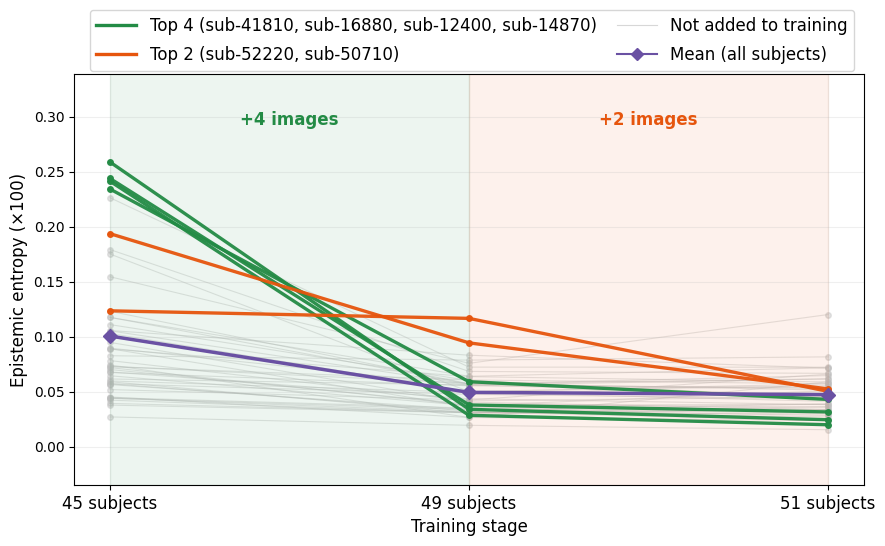

In [77]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

DATA_DIR = Path(".")
STAGE_FILES = {
    1: DATA_DIR / "results/entropy/outliers_45_entropy_seed2025.json",
    2: DATA_DIR / "results/entropy/outliers_49_entropy.json",
    3: DATA_DIR / "results/entropy/outliers_51_entropy.json",
}

SCALE = 100  # match heatmap display (entropy × 100)


def entropy_value(record):
    if isinstance(record, dict):
        return float(record["epistemic_entropy"])
    return float(record)


def top_entropy_subjects(path, n):
    with open(path) as f:
        data = {subject: entropy_value(record) for subject, record in json.load(f).items()}
    ranked = sorted(data.items(), key=lambda item: item[1], reverse=True)
    return [subject for subject, _ in ranked[:n]]


def short_subject(case_name):
    return case_name.split(".")[0]


def load_entropy_by_stage():
    stages = {}
    for stage, path in STAGE_FILES.items():
        with open(path) as f:
            stages[stage] = {
                subject: entropy_value(record)
                for subject, record in json.load(f).items()
            }
    subjects = sorted(stages[1].keys())
    matrix = np.array([[stages[s][subj] for s in (1, 2, 3)] for subj in subjects])
    order = np.argsort(matrix[:, 0])[::-1]
    subjects = [subjects[i] for i in order]
    return subjects, matrix[order]


subjects, entropy = load_entropy_by_stage()
s1, s2, s3 = (entropy[:, i] * SCALE for i in range(3))

added_1_to_2 = top_entropy_subjects(STAGE_FILES[1], 4)
added_2_to_3 = top_entropy_subjects(STAGE_FILES[2], 2)
subject_to_idx = {subject: i for i, subject in enumerate(subjects)}
new_training_stage2 = np.array([subject_to_idx[s] for s in added_1_to_2])
new_training_stage3 = np.array([subject_to_idx[s] for s in added_2_to_3])
added_training_indices = np.unique(np.concatenate([new_training_stage2, new_training_stage3]))

STAGE_X_LABELS = ["45 subjects", "49 subjects", "51 subjects"]
STAGES = np.array([1, 2, 3])

subject_idx = np.arange(len(s1))
entropy_scaled = entropy * SCALE

# Widen spacing among newly labeled subjects; rest stay evenly spaced
NEW_SPREAD = 3.0

plot_x = np.zeros(len(s1))
for rank, idx in enumerate(sorted(added_training_indices)):
    plot_x[idx] = rank * NEW_SPREAD
next_x = plot_x[sorted(added_training_indices)[-1]] if len(added_training_indices) else 0
for i in range(len(s1)):
    if i not in added_training_indices:
        next_x += 1
        plot_x[i] = next_x

ADDED_1_TO_2 = "#238b45"  # labeled before stage 2 (subj. 0–3)
ADDED_2_TO_3 = "#08519c"  # labeled before stage 3 (subj. 4–5)
STAGE_STYLE = [
    ("o", "#6a51a3"),
    ("s", "#54278f"),
    ("^", "#3f007d"),
]


ADDED_2_TO_3_FIG2 = "#e6550d"  # orange — distinct from green (stage 2→3 only in this figure)

fig2, ax = plt.subplots(figsize=(9, 6))

for i in range(len(s1)):
    if i in new_training_stage2:
        color, lw, alpha, z = ADDED_1_TO_2, 2.4, 0.95, 4
    elif i in new_training_stage3:
        color, lw, alpha, z = ADDED_2_TO_3_FIG2, 2.4, 0.95, 4
    else:
        color, lw, alpha, z = "#bdbdbd", 0.8, 0.4, 1
    ax.plot(STAGES, entropy_scaled[i], "-o", color=color, lw=lw, alpha=alpha, ms=4, zorder=z)

ax.plot(STAGES, entropy_scaled.mean(axis=0), "D-", color="#6a51a3", lw=2.5, ms=7, zorder=5)
ax.axvspan(1.0, 2.0, color=ADDED_1_TO_2, alpha=0.08)
ax.axvspan(2.0, 3.0, color=ADDED_2_TO_3_FIG2, alpha=0.08)
ax.text(1.5, entropy_scaled.max() + 0.03, "+4 images", ha="center", va="bottom", fontsize=12, color=ADDED_1_TO_2, fontweight="bold")
ax.text(2.5, entropy_scaled.max() + 0.03, "+2 images", ha="center", va="bottom", fontsize=12, color=ADDED_2_TO_3_FIG2, fontweight="bold")
ax.set_ylim(entropy_scaled.min() - 0.05, entropy_scaled.max() + 0.08)
ax.set_xticks(STAGES, STAGE_X_LABELS, fontsize=12)
ax.set_xlabel("Training stage", fontsize=12)
ax.set_ylabel("Epistemic entropy (×100)", fontsize=12)
ax.grid(True, alpha=0.2)

right_legend = [
    Line2D(
        [0], [0],
        color=ADDED_1_TO_2,
        lw=2.4,
        label=f"Top 4 ({', '.join(short_subject(s) for s in added_1_to_2)})",
    ),
    Line2D(
        [0], [0],
        color=ADDED_2_TO_3_FIG2,
        lw=2.4,
        label=f"Top 2 ({', '.join(short_subject(s) for s in added_2_to_3)})",
    ),
    Line2D([0], [0], color="#bdbdbd", lw=0.8, alpha=0.6, label="Not added to training"),
    Line2D([0], [0], color="#6a51a3", marker="D", linestyle="-", ms=6, label="Mean (all subjects)"),
]
fig2.legend(
    handles=right_legend,
    loc="upper center",
    bbox_to_anchor=(0.53, 0.913),
    ncol=2,
    frameon=True,
    fontsize=12,
    handlelength=2.4,
    labelspacing=0.7,
    columnspacing=1.2,
    borderaxespad=0.4,
)
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.savefig("/scratch/user/uqxye5/segmentation/ALMRI/results/entropy_changes.pdf", dpi=300)
plt.show()

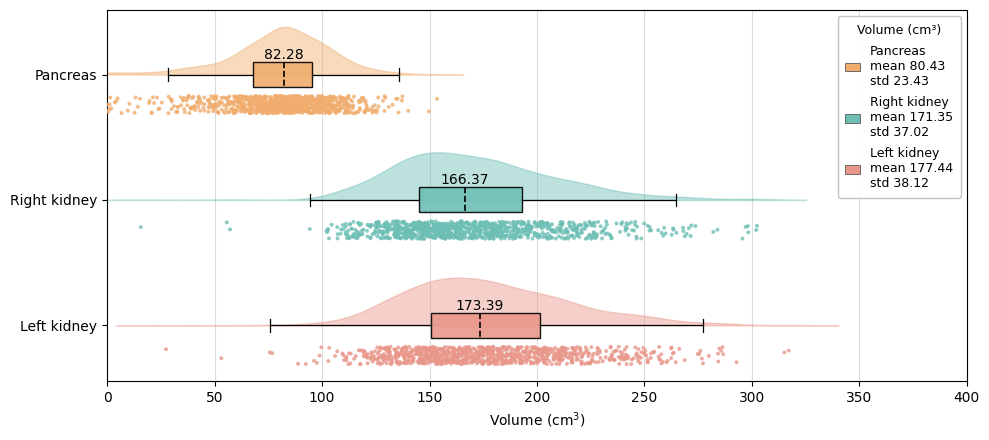

Saved figure to /scratch/user/uqxye5/segmentation/ALMRI/results/entropy_active_51_volume_raincloud.pdf
Cases: 960


,mean,std
organ_label,,
Pancreas,80.428521,23.427117
Right kidney,171.345956,37.022979
Left kidney,177.444916,38.124717


In [18]:
import os
from glob import glob

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

ALMRI_DIR = '/scratch/user/uqxye5/segmentation/ALMRI'
predictions_path = '/scratch/project/bollmann_lab/Xincheng/segmentation/ALMRI/predictions/segmentation960_3organs_entropy_finetune_51'

ORGANS = ["left_kidney", "right_kidney", "pancreas"]
ORGAN_LABELS = ["Left kidney", "Right kidney", "Pancreas"]
ORGAN_COLORS = {
    "left_kidney": "#E9978A",
    "right_kidney": "#6DBFB5",
    "pancreas": "#F0AD6E",
}
ORGAN_LABEL_IDS = {1: "left_kidney", 2: "right_kidney", 3: "pancreas"}
MM3_PER_CM3 = 1000.0


def nifti_voxel_spacing_mm(img: nib.Nifti1Image) -> tuple[float, float, float]:
    zooms = nib.affines.voxel_sizes(img.affine)
    return tuple(float(abs(z)) for z in zooms[:3])


def organ_volumes_from_pred(pred_path: str) -> dict:
    img = nib.load(pred_path)
    data = np.asarray(img.dataobj)
    sx, sy, sz = nifti_voxel_spacing_mm(img)
    voxel_mm3 = sx * sy * sz
    n_voxels = {
        ORGAN_LABEL_IDS[label_id]: int((data == label_id).sum())
        for label_id in ORGAN_LABEL_IDS
    }
    volume_cm3 = {
        organ: n_voxels[organ] * voxel_mm3 / MM3_PER_CM3 for organ in n_voxels
    }
    return {"volume_cm3": volume_cm3}


def collect_pred_volumes(pred_dir: str, organs=ORGANS) -> pd.DataFrame:
    rows = []
    for pred_path in sorted(glob(os.path.join(pred_dir, "*.nii.gz"))):
        case = os.path.basename(pred_path)
        parsed = organ_volumes_from_pred(pred_path)
        for organ in organs:
            rows.append(
                {
                    "case": case,
                    "organ": organ,
                    "volume": parsed["volume_cm3"][organ],
                }
            )
    return pd.DataFrame(rows)


def plot_raincloud_horizontal(
    ax,
    data,
    x_col,
    y_col,
    order,
    palette,
    *,
    cloud_height=0.38,
    rain_gap=0.24,
    box_w=0.2,
    cloud_alpha=0.45,
    point_size=8,
    rng=None,
    annotate_median=True,
):
    if rng is None:
        rng = np.random.default_rng(0)
    y_at = {lab: i for i, lab in enumerate(order)}

    for lab in order:
        vals = data.loc[data[y_col] == lab, x_col].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        color = palette[lab]
        y0 = y_at[lab]

        ax.boxplot(
            vals,
            positions=[y0],
            vert=False,
            widths=box_w,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            flierprops=dict(marker="o", markersize=4, markerfacecolor="none", markeredgecolor="0.45"),
            zorder=3,
            boxprops=dict(facecolor=color, edgecolor="black", alpha=0.9, linewidth=1),
            medianprops=dict(color="black", linestyle="--", linewidth=1.2),
            whiskerprops=dict(color="black", linewidth=0.9),
            capprops=dict(color="black", linewidth=0.9),
        )

        if annotate_median:
            median = float(np.median(vals))
            ax.text(
                median,
                y0 - 0.1,
                f"{median:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
                color="black",
                zorder=6,
            )

        jitter = rng.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(
            vals,
            y0 + rain_gap + jitter,
            s=point_size,
            color=color,
            alpha=0.8,
            edgecolors="none",
            zorder=4,
        )

        if len(vals) >= 2:
            kde = gaussian_kde(vals)
            pad = max(1.0, 0.08 * (vals.max() - vals.min()))
            xs = np.linspace(max(0, vals.min() - pad), vals.max() + pad, 200)
            dens = kde(xs)
            dens = dens / dens.max() * cloud_height
            ax.fill_between(xs, y0 - dens, y0, color=color, alpha=cloud_alpha, zorder=1)

    ax.set_yticks(range(len(order)), order)
    ax.invert_yaxis()


df_pred_vol = collect_pred_volumes(predictions_path)
organ_label_map = dict(zip(ORGANS, ORGAN_LABELS))
df_pred_vol["organ_label"] = df_pred_vol["organ"].map(organ_label_map)

ORGAN_Y_LABELS = ["Pancreas", "Right kidney", "Left kidney"]
palette = {organ_label_map[o]: ORGAN_COLORS[o] for o in ORGANS}

vol_stats = (
    df_pred_vol.groupby("organ_label")["volume"]
    .agg(mean="mean", std="std")
    .reindex(ORGAN_Y_LABELS)
)

vol_max = np.ceil(df_pred_vol["volume"].max() / 100) * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_raincloud_horizontal(
    ax,
    df_pred_vol,
    x_col="volume",
    y_col="organ_label",
    order=ORGAN_Y_LABELS,
    palette=palette,
    rng=np.random.default_rng(42),
)

ax.set_xlim(0, vol_max)
ax.set_xlabel(r"Volume ($\mathrm{cm}^3$)")
ax.set_axisbelow(True)
ax.grid(axis="x", color="0.85", linestyle="-", linewidth=0.8, alpha=0.9)
ax.set_facecolor("white")

legend_handles = [
    Patch(facecolor=palette[lab], edgecolor="0.35", linewidth=0.6)
    for lab in ORGAN_Y_LABELS
]
legend_labels = [
    f"{lab}\nmean {vol_stats.loc[lab, 'mean']:.2f}\nstd {vol_stats.loc[lab, 'std']:.2f}"
    for lab in ORGAN_Y_LABELS
]
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="0.75",
    fontsize=9,
    handlelength=1.2,
    labelspacing=0.65,
    borderpad=0.6,
    title="Volume (cm³)",
    title_fontsize=9,
)

plt.tight_layout()
out_path = os.path.join(ALMRI_DIR, "results", "entropy_active_51_volume_raincloud.pdf")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {out_path}")
print(f"Cases: {df_pred_vol['case'].nunique()}")
vol_stats


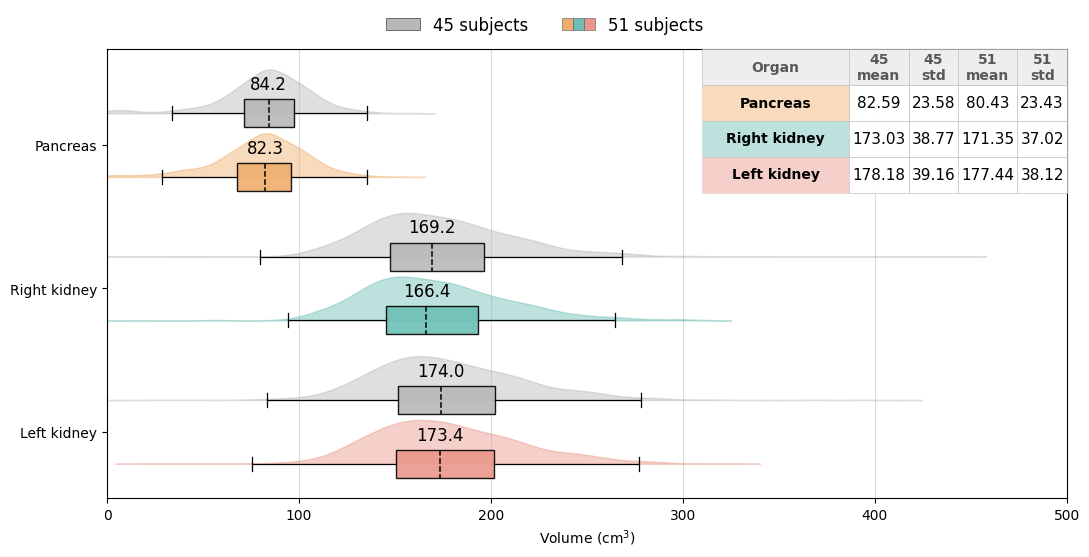

Saved figure to /scratch/user/uqxye5/segmentation/ALMRI/results/entropy_active45_vs_finetune51_volume_raincloud.pdf
Cases per method: {'45 subjects': 960, '51 subjects': 960}


mean        std      median
method      organ_label                                    
45 subjects Left kidney   178.180185  39.164618  174.048092
            Pancreas       82.586057  23.580091   84.222104
            Right kidney  173.028641  38.768335  169.184948
51 subjects Left kidney   177.444916  38.124717  173.387238
            Pancreas       80.428521  23.427117   82.278222
            Right kidney  171.345956  37.022979  166.365847

In [33]:
import os
from glob import glob

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

ALMRI_DIR = '/scratch/user/uqxye5/segmentation/ALMRI'

PREVIOUS_PRED_PATH = (
    "/scratch/project/bollmann_lab/Xincheng/segmentation/ALMRI/predictions/"
    "segmentation960_3organs_entropy_active_45"
)
FINETUNE_PRED_PATH = (
    "/scratch/project/bollmann_lab/Xincheng/segmentation/ALMRI/predictions/"
    "segmentation960_3organs_entropy_finetune_51"
)

METHOD_ORDER = ["45 subjects", "51 subjects"]
METHOD_OFFSET = 0.16
PREVIOUS_COLOR = "#B8B8B8"
CURRENT_METHOD = METHOD_ORDER[1]

ORGANS = ["left_kidney", "right_kidney", "pancreas"]
ORGAN_LABELS = ["Left kidney", "Right kidney", "Pancreas"]
ORGAN_COLORS = {
    "left_kidney": "#E9978A",
    "right_kidney": "#6DBFB5",
    "pancreas": "#F0AD6E",
}
ORGAN_LABEL_IDS = {1: "left_kidney", 2: "right_kidney", 3: "pancreas"}
MM3_PER_CM3 = 1000.0

def nifti_voxel_spacing_mm(img: nib.Nifti1Image) -> tuple[float, float, float]:
    zooms = nib.affines.voxel_sizes(img.affine)
    return tuple(float(abs(z)) for z in zooms[:3])


def organ_volumes_from_pred(pred_path: str) -> dict:
    img = nib.load(pred_path)
    data = np.asarray(img.dataobj)
    sx, sy, sz = nifti_voxel_spacing_mm(img)
    voxel_mm3 = sx * sy * sz
    n_voxels = {
        ORGAN_LABEL_IDS[label_id]: int((data == label_id).sum())
        for label_id in ORGAN_LABEL_IDS
    }
    volume_cm3 = {
        organ: n_voxels[organ] * voxel_mm3 / MM3_PER_CM3 for organ in n_voxels
    }
    return {"volume_cm3": volume_cm3}


def collect_pred_volumes(pred_dir: str, organs=ORGANS) -> pd.DataFrame:
    rows = []
    for pred_path in sorted(glob(os.path.join(pred_dir, "*.nii.gz"))):
        case = os.path.basename(pred_path)
        parsed = organ_volumes_from_pred(pred_path)
        for organ in organs:
            rows.append(
                {
                    "case": case,
                    "organ": organ,
                    "volume": parsed["volume_cm3"][organ],
                }
            )
    return pd.DataFrame(rows)


def collect_pred_volumes(pred_dir: str, organs=ORGANS) -> pd.DataFrame:
    rows = []
    for pred_path in sorted(glob(os.path.join(pred_dir, "*.nii.gz"))):
        case = os.path.basename(pred_path)
        parsed = organ_volumes_from_pred(pred_path)
        for organ in organs:
            rows.append(
                {
                    "case": case,
                    "organ": organ,
                    "volume": parsed["volume_cm3"][organ],
                }
            )
    return pd.DataFrame(rows)

def plot_raincloud_comparison(
    ax,
    data,
    x_col,
    organ_col,
    method_col,
    organ_order,
    method_order,
    palette,
    *,
    previous_color=PREVIOUS_COLOR,
    cloud_height=0.22,
    rain_gap=0.12,
    box_w=0.14,
    cloud_alpha=0.45,
    point_size=6,
    rng=None,
    annotate_median=True,
    show_dots=False,
):
    if rng is None:
        rng = np.random.default_rng(0)

    organ_y = {lab: i * 0.72 for i, lab in enumerate(organ_order)}
    method_shift = {
        method_order[0]: -METHOD_OFFSET,
        method_order[1]: METHOD_OFFSET,
    }

    for organ in organ_order:
        organ_color = palette[organ]
        y_base = organ_y[organ]
        for method in method_order:
            vals = data.loc[
                (data[organ_col] == organ) & (data[method_col] == method), x_col
            ].to_numpy(dtype=float)
            if len(vals) == 0:
                continue

            color = previous_color if method == method_order[0] else organ_color
            y0 = y_base + method_shift[method]
            ax.boxplot(
                vals,
                positions=[y0],
                vert=False,
                widths=box_w,
                patch_artist=True,
                manage_ticks=False,
                showfliers=False,
                zorder=3,
                boxprops=dict(facecolor=color, edgecolor="black", alpha=0.9, linewidth=1),
                medianprops=dict(color="black", linestyle="--", linewidth=1.1),
                whiskerprops=dict(color="black", linewidth=0.9),
                capprops=dict(color="black", linewidth=0.9),
            )

            if annotate_median:
                median = float(np.median(vals))
                ax.text(
                    median,
                    y0 - 0.1,
                    f"{median:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    color="black",
                    zorder=6,
                )

            jitter = rng.uniform(-0.04, 0.04, size=len(vals))
            if show_dots:
                ax.scatter(
                    vals,
                    y0 + rain_gap + jitter,
                    s=point_size,
                    color=color,
                    alpha=0.85,
                    edgecolors="none",
                    zorder=4,
                )

            if len(vals) >= 2:
                kde = gaussian_kde(vals)
                pad = max(1.0, 0.08 * (vals.max() - vals.min()))
                xs = np.linspace(max(0, vals.min() - pad), vals.max() + pad, 200)
                dens = kde(xs)
                dens = dens / dens.max() * cloud_height
                ax.fill_between(xs, y0 - dens, y0, color=color, alpha=cloud_alpha, zorder=1)

    ax.set_yticks([organ_y[lab] for lab in organ_order], organ_order)
    ax.invert_yaxis()


df_prev = collect_pred_volumes(PREVIOUS_PRED_PATH)
df_prev["method"] = METHOD_ORDER[0]
df_finetune = collect_pred_volumes(FINETUNE_PRED_PATH)
df_finetune["method"] = METHOD_ORDER[1]

df_vol_compare = pd.concat([df_prev, df_finetune], ignore_index=True)
organ_label_map = dict(zip(ORGANS, ORGAN_LABELS))
df_vol_compare["organ_label"] = df_vol_compare["organ"].map(organ_label_map)

ORGAN_Y_LABELS = ["Pancreas", "Right kidney", "Left kidney"]
palette = {organ_label_map[o]: ORGAN_COLORS[o] for o in ORGANS}

vol_stats_compare = (
    df_vol_compare.groupby(["method", "organ_label"])["volume"]
    .agg(mean="mean", std="std", median="median")
    .reindex(METHOD_ORDER, level=0)
)
PREVIOUS_METHOD = METHOD_ORDER[0]
previous_stats = vol_stats_compare.loc[PREVIOUS_METHOD].reindex(ORGAN_Y_LABELS)
current_stats = vol_stats_compare.loc[CURRENT_METHOD].reindex(ORGAN_Y_LABELS)

vol_max = np.ceil(df_vol_compare["volume"].max() / 100) * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_raincloud_comparison(
    ax,
    df_vol_compare,
    x_col="volume",
    organ_col="organ_label",
    method_col="method",
    organ_order=ORGAN_Y_LABELS,
    method_order=METHOD_ORDER,
    palette=palette,
    rng=np.random.default_rng(42),
)

ax.set_xlim(0, vol_max)
ax.set_xlabel(r"Volume ($\mathrm{cm}^3$)")
ax.set_axisbelow(True)
ax.grid(axis="x", color="0.85", linestyle="-", linewidth=0.8, alpha=0.9)
ax.set_facecolor("white")

from matplotlib.legend_handler import HandlerTuple

finetune_stripe = tuple(
    Patch(facecolor=palette[lab], edgecolor="0.35", linewidth=0.4)
    for lab in ORGAN_Y_LABELS
)
method_handles = [
    Patch(facecolor=PREVIOUS_COLOR, edgecolor="0.35", linewidth=0.6),
    finetune_stripe,
]
method_labels = METHOD_ORDER

table_data = [
    [
        lab,
        f"{previous_stats.loc[lab, 'mean']:.2f}",
        f"{previous_stats.loc[lab, 'std']:.2f}",
        f"{current_stats.loc[lab, 'mean']:.2f}",
        f"{current_stats.loc[lab, 'std']:.2f}",
    ]
    for lab in ORGAN_Y_LABELS
]
col_labels = ["Organ", "45\nmean", "45\nstd", "51\nmean", "51\nstd"]

HEADER_FONT = 10
DATA_FONT = 11


def max_line_len(text):
    return max(len(line) for line in str(text).split("\n"))


col_texts = [[label] for label in col_labels]
for row in table_data:
    for col, val in enumerate(row):
        col_texts[col].append(str(val))

# Width weights from content length; column 0 uses slightly wider per-char scale.
char_scale = [0.062, 0.050, 0.050, 0.050, 0.050]
col_widths = [
    max(max(max_line_len(t) for t in texts) * char_scale[col], 0.08)
    for col, texts in enumerate(col_texts)
]
col_widths = [w / sum(col_widths) for w in col_widths]
table_bbox_w = 0.018 * sum(max_line_len(t) for texts in col_texts for t in texts) + 0.06
table_bbox_w = min(max(table_bbox_w, 0.22), 0.38)

stats_table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="upper right",
    bbox=[1.0 - table_bbox_w, 0.68, table_bbox_w, 0.32],
    cellLoc="center",
    zorder=10,
)
stats_table.auto_set_font_size(False)

for (row, col), cell in stats_table.get_celld().items():
    cell.PAD = 0.01
    cell.set_edgecolor("0.75")
    cell.set_linewidth(0.5)
    cell.set_alpha(0.92)
    cell.set_width(col_widths[col])
    if row == 0:
        cell.set_facecolor("0.93")
        cell.set_text_props(weight="bold", fontsize=HEADER_FONT, color="0.35")
    elif col == 0:
        organ = ORGAN_Y_LABELS[row - 1]
        cell.set_facecolor(palette[organ])
        cell.set_alpha(0.45)
        cell.set_text_props(fontsize=DATA_FONT - 1, weight="bold")
    else:
        cell.set_facecolor("white")
        cell.set_text_props(fontsize=DATA_FONT)

fig.legend(
    handles=method_handles,
    labels=method_labels,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=12,
    handlelength=2.0,
    # title="Model",
    title_fontsize=10,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
out_path = os.path.join(
    ALMRI_DIR, "results", "entropy_active45_vs_finetune51_volume_raincloud.pdf"
)
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.savefig(out_path.replace(".pdf", ".png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {out_path}")
print(f"Cases per method: {df_vol_compare.groupby('method')['case'].nunique().to_dict()}")
vol_stats_compare

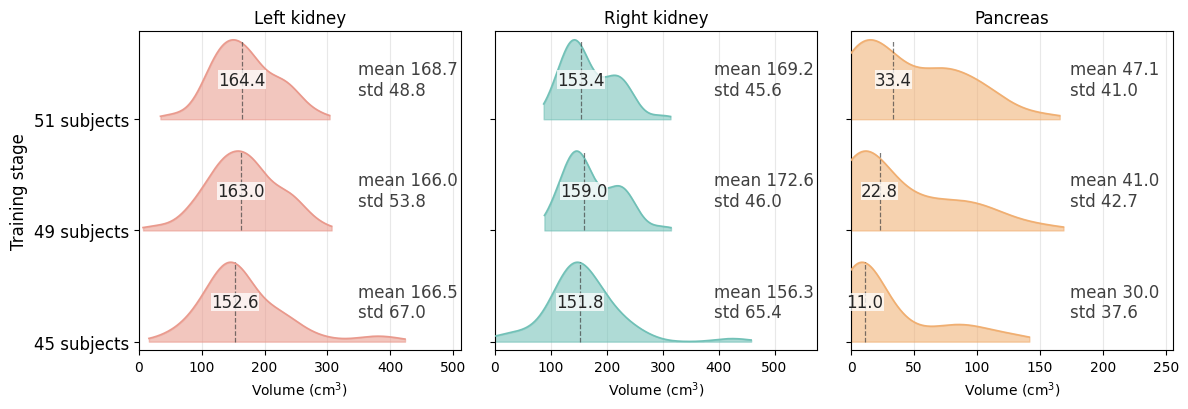

Saved figure to /scratch/user/uqxye5/segmentation/ALMRI/results/outliers45_volume_ridges_45_49_51.pdf
Cases per stage: {'45': 46, '49': 46, '51': 46}


mean        std      median
stage organ_label                                    
45    Left kidney   166.510558  66.973269  152.586656
      Pancreas       29.959820  37.623391   11.010569
      Right kidney  156.327147  65.445680  151.768051
49    Left kidney   166.049912  53.752835  163.026407
      Pancreas       40.976193  42.713688   22.772713
      Right kidney  172.640273  46.027980  158.963047
51    Left kidney   168.723884  48.782426  164.448313
      Pancreas       47.088990  40.982771   33.447717
      Right kidney  169.237203  45.586528  153.365271

In [57]:
import os
from glob import glob

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

ALMRI_DIR = "/scratch/user/uqxye5/segmentation/ALMRI"
prediction_45_path = os.path.join(ALMRI_DIR, "datasets/prediction45_outliers_45")
prediction_49_path = os.path.join(ALMRI_DIR, "datasets/prediction49_outliers_45")
prediction_51_path = os.path.join(ALMRI_DIR, "datasets/prediction51_outliers_45")

ORGANS = ["left_kidney", "right_kidney", "pancreas"]
ORGAN_LABELS = ["Left kidney", "Right kidney", "Pancreas"]
ORGAN_COLORS = {
    "left_kidney": "#E9978A",
    "right_kidney": "#6DBFB5",
    "pancreas": "#F0AD6E",
}
ORGAN_LABEL_IDS = {1: "left_kidney", 2: "right_kidney", 3: "pancreas"}
MM3_PER_CM3 = 1000.0

STAGE_ORDER = ["45", "49", "51"]
STAGE_PATHS = {
    "45": prediction_45_path,
    "49": prediction_49_path,
    "51": prediction_51_path,
}
STAGE_LABELS = {
    "45": "45 subjects",
    "49": "49 subjects",
    "51": "51 subjects",
}


def nifti_voxel_spacing_mm(img: nib.Nifti1Image) -> tuple[float, float, float]:
    zooms = nib.affines.voxel_sizes(img.affine)
    return tuple(float(abs(z)) for z in zooms[:3])


def organ_volumes_from_pred(pred_path: str) -> dict:
    img = nib.load(pred_path)
    data = np.asarray(img.dataobj)
    sx, sy, sz = nifti_voxel_spacing_mm(img)
    voxel_mm3 = sx * sy * sz
    n_voxels = {
        ORGAN_LABEL_IDS[label_id]: int((data == label_id).sum())
        for label_id in ORGAN_LABEL_IDS
    }
    volume_cm3 = {
        organ: n_voxels[organ] * voxel_mm3 / MM3_PER_CM3 for organ in n_voxels
    }
    return {"volume_cm3": volume_cm3}


def collect_pred_volumes(pred_dir: str, stage: str, organs=ORGANS) -> pd.DataFrame:
    rows = []
    for pred_path in sorted(glob(os.path.join(pred_dir, "*.nii.gz"))):
        case = os.path.basename(pred_path)
        parsed = organ_volumes_from_pred(pred_path)
        for organ in organs:
            rows.append(
                {
                    "case": case,
                    "organ": organ,
                    "stage": stage,
                    "volume": parsed["volume_cm3"][organ],
                }
            )
    return pd.DataFrame(rows)


def plot_stage_ridges(
    ax,
    values,
    y_base,
    color,
    *,
    ridge_height=0.75,
    alpha=0.55,
    x_stats=None,
):
    vals = np.asarray(values, dtype=float)
    if len(vals) == 0:
        return
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    median = float(np.median(vals))

    if len(vals) >= 2:
        kde = gaussian_kde(vals)
        pad = max(1.0, 0.08 * (vals.max() - vals.min()))
        xs = np.linspace(max(0, vals.min() - pad), vals.max() + pad, 200)
        dens = kde(xs)
        dens = dens / dens.max() * ridge_height
        ax.fill_between(xs, y_base, y_base + dens, color=color, alpha=alpha, zorder=2)
        ax.plot(xs, y_base + dens, color=color, lw=1.2, alpha=0.95, zorder=3)

    ax.plot(
        [median, median],
        [y_base, y_base + ridge_height],
        color="0.25",
        ls="--",
        lw=0.9,
        alpha=0.7,
        zorder=4,
    )
    ax.text(
        median,
        y_base + ridge_height * 0.5,
        f"{median:.1f}",
        ha="center",
        va="center",
        fontsize=12,
        color="0.15",
        zorder=5,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.15),
    )
    if x_stats is not None:
        ax.text(
            x_stats,
            y_base + ridge_height * 0.5,
            f"mean {mean:.1f}\nstd {std:.1f}",
            ha="left",
            va="center",
            fontsize=12,
            color="0.25",
            zorder=5,
        )


df_stage_vol = pd.concat(
    [collect_pred_volumes(path, stage) for stage, path in STAGE_PATHS.items()],
    ignore_index=True,
)
organ_label_map = dict(zip(ORGANS, ORGAN_LABELS))
label_to_organ = {label: organ for organ, label in organ_label_map.items()}
df_stage_vol["organ_label"] = df_stage_vol["organ"].map(organ_label_map)

vol_stats = (
    df_stage_vol.groupby(["stage", "organ_label"])["volume"]
    .agg(mean="mean", std="std", median="median")
    .reindex(STAGE_ORDER, level=0)
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
ridge_gap = 1.05
ridge_height = 0.75

for ax, organ in zip(axes, ORGAN_LABELS):
    organ_df = df_stage_vol[df_stage_vol["organ_label"] == organ]
    color = ORGAN_COLORS[label_to_organ[organ]]
    organ_max = np.ceil(organ_df["volume"].max() / 50) * 50
    x_stats = organ_max * 0.87

    for i, stage in enumerate(STAGE_ORDER):
        vals = organ_df.loc[organ_df["stage"] == stage, "volume"].to_numpy(dtype=float)
        y_base = i * ridge_gap
        plot_stage_ridges(
            ax,
            vals,
            y_base,
            color,
            ridge_height=ridge_height,
            x_stats=x_stats,
        )

    ax.set_yticks([i * ridge_gap for i in range(len(STAGE_ORDER))], [STAGE_LABELS[s] for s in STAGE_ORDER], fontsize=12)
    ax.set_ylim(-0.08, (len(STAGE_ORDER) - 1) * ridge_gap + ridge_height + 0.08)
    ax.set_xlim(0, organ_max * 1.28)
    ax.set_xlabel(r"Volume ($\mathrm{cm}^3$)")
    ax.set_title(organ, fontsize=12)
    ax.grid(axis="x", color="0.9", lw=0.8, alpha=0.9)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Training stage", fontsize=12)
# fig.suptitle("Predicted organ volume distributions across training stages", y=1.02, fontsize=11)

# fig.legend(
#     handles=[
#         Line2D([0], [0], color="0.25", ls="--", lw=0.9, label="Median"),
#     ],
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.08),
#     ncol=2,
#     frameon=False,
#     fontsize=9,
# )

plt.tight_layout()
out_path = os.path.join(ALMRI_DIR, "results", "outliers45_volume_ridges_45_49_51.pdf")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.savefig(out_path.replace(".pdf", ".png"), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {out_path}")
print(f"Cases per stage: {df_stage_vol.groupby('stage')['case'].nunique().to_dict()}")
vol_stats